# Лабораторная работа 1.1 — Калибровка призменного спектрометра

**Пошаговое руководство** (можно повторить для любой калибровочной кривой).

Задача: по известным спектральным линиям $\lambda$ и снятым отсчётам барабана
$\varphi$ построить дисперсионную кривую и аппроксимировать её формулой Гартмана
$$\lambda = \lambda_0 + \frac{C}{\varphi - \varphi_0}.$$

Схема работы (те же шаги подойдут для другой лабы):
1. данные → 2. погрешности → 3. модель и стартовое приближение →
4. аппроксимация и график → 5. параметры → 6. пользуемся калибровкой.

## Шаг 1. Импорт

`gostplot` лежит рядом с ноутбуком (`gostplot.py`). Нужны `numpy`, `scipy`,
`matplotlib` в окружении.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from gostplot import GostPlot

## Шаг 2. Данные

Договоримся об осях так, как калибровкой потом **пользуются**: измеряем отсчёт
барабана → получаем длину волны. Значит:

- **X = $\varphi$** (`position`) — отсчёт барабана, дел. (измеряется напрямую);
- **Y = $\lambda$** (`wave_length_nm`) — табличная длина волны, нм.

In [4]:
wave_length_nm = np.array([671.7, 667.8, 659.9, 653.3, 650.7, 640.2, 638.3, 633.4, 630.5, 626.7,
                           621.7, 616.4, 614.3, 609.6, 607.4, 603, 597.6, 594.5, 588.2, 585.2,
                           540.1, 533.6], dtype=float)
position = np.array([2495, 2489, 2475, 2446, 2435, 2390, 2386, 2377, 2347, 2339,
                     2330, 2293, 2289, 2278, 2249, 2239, 2200, 2193, 2178, 2145,
                     1890, 1842], dtype=float)
assert len(wave_length_nm) == len(position)
wave_length_nm

array([671.7, 667.8, 659.9, 653.3, 650.7, 640.2, 638.3, 633.4, 630.5,
       626.7, 621.7, 616.4, 614.3, 609.6, 607.4, 603. , 597.6, 594.5,
       588.2, 585.2, 540.1, 533.6])

## Шаг 3. Погрешности

Правило: погрешность = точность прибора, а не «на глаз».

- $\Delta\varphi = 0.5$ дел. — половина наименьшего деления барабана (ось X);
- $\Delta\lambda = 0.3$ нм — табличная погрешность длины волны (ось Y).

In [5]:
dphi = 0.5   # дел.  (X)
dlam = 0.3   # нм    (Y)

## Шаг 4 (справочно). «Ручной» способ через matplotlib

Так выглядит тот же график на голом `matplotlib` — без стиля ГОСТ и без
аппроксимации. Дальше делаем то же самое одной цепочкой в `gostplot`.

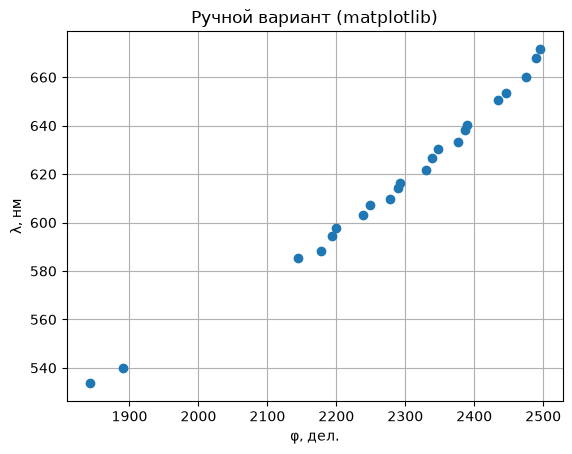

In [6]:
plt.errorbar(position, wave_length_nm, xerr=dphi, yerr=dlam, fmt='o')
plt.xlabel('φ, дел.')
plt.ylabel('λ, нм')
plt.title('Ручной вариант (matplotlib)')
plt.grid(True)
plt.show()

## Шаг 5. Модель Гартмана и стартовое приближение

$\lambda = \lambda_0 + C/(\varphi - \varphi_0)$.

Важно: полюс $\varphi_0$ лежит **выше** диапазона данных ($\varphi_0 \approx 3700 >
\varphi_{\max}$). Если задать `p0` с полюсом внутри данных, `curve_fit` не сойдётся.

In [7]:
def hartmann(phi, lam0, C, phi0):
    return lam0 + C / (phi - phi0)

p0 = [294, -4.2e5, 3621]   # lam0, C, phi0  — стартовое приближение

## Шаг 6. Выбор модели калибровки

Запусти **ОДНУ** из двух ячеек ниже (дизайн идентичный). Каждая определяет
`phi_to_lambda(φ)` и `lambda_err(φ)` — весь низ ноутбука использует ту модель,
которую ты запустил последней.

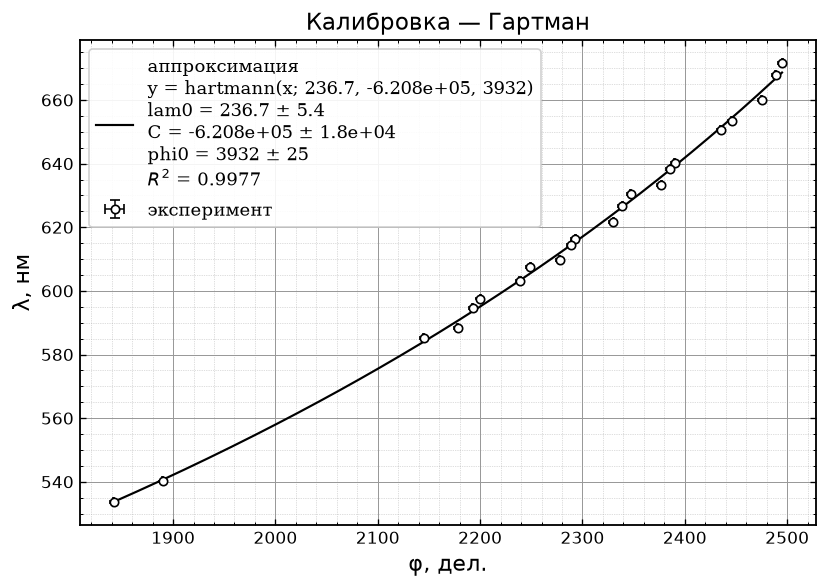

lam0 = 236.7 ± 5.4
C = -6.208e+05 ± 1.8e+04
phi0 = 3932 ± 25 
R² = 0.99771  |  σ_λ(RMS) = 1.69 нм


In [8]:
# ═══ МОДЕЛЬ A · Гартман ═══   (запусти ЭТУ или B)
calib = (GostPlot(position, wave_length_nm)
         .xlabel('φ', 'дел.').ylabel('λ', 'нм')
         .title('Калибровка — Гартман')
         .errors(dy=dlam, dx=dphi)
         .fit(hartmann, p0=p0))
lam0, C, phi0 = calib.result.params

def phi_to_lambda(phi):                       # φ → λ
    phi = np.asarray(phi, float)
    return lam0 + C / (phi - phi0)

# σ_λ стадия 1 — от точности отсчёта Δφ (производная численно)
def lambda_err_input(phi, h=1e-3):
    phi = np.asarray(phi, float)
    dldphi = (phi_to_lambda(phi + h) - phi_to_lambda(phi - h)) / (2*h)
    return np.abs(dldphi) * dphi

# σ_λ стадия 2 — от разброса точек калибровки (RMS остатков)
sigma_lam = np.sqrt(np.mean((phi_to_lambda(position) - wave_length_nm)**2))
def lambda_err_rms(phi):
    return np.full_like(np.asarray(phi, float), sigma_lam)

calib.show()
print(calib.result.report, f'\nR² = {calib.result.r2:.5f}  |  σ_λ(RMS) = {sigma_lam:.2f} нм')

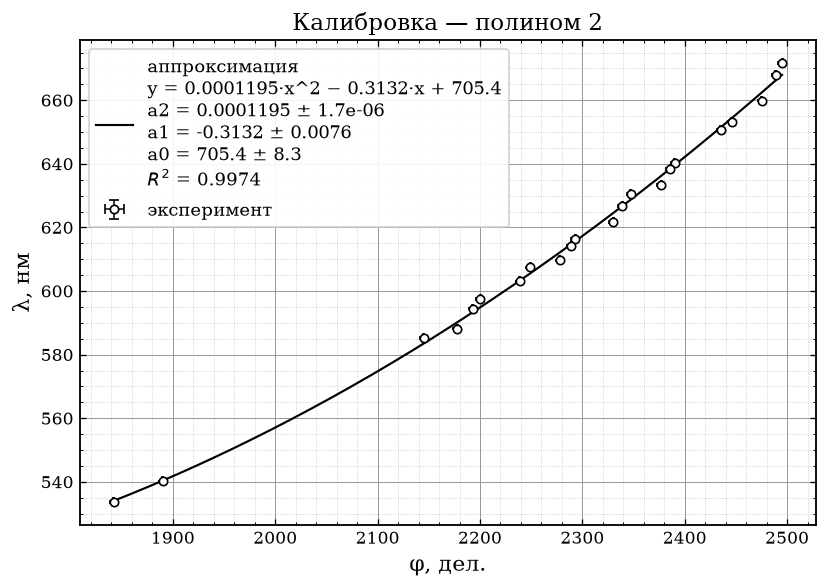

a2 = 0.0001195 ± 1.7e-06
a1 = -0.3132 ± 0.0076
a0 = 705.4 ± 8.3 
R² = 0.99742  |  σ_λ(RMS) = 1.79 нм


In [9]:
# ═══ МОДЕЛЬ B · полином 2-й степени ═══   (запусти ЭТУ или A)
calib = (GostPlot(position, wave_length_nm)
         .xlabel('φ', 'дел.').ylabel('λ', 'нм')
         .title('Калибровка — полином 2')
         .errors(dy=dlam, dx=dphi)
         .fit(2))
a2, a1, a0 = calib.result.params

def phi_to_lambda(phi):                       # φ → λ
    phi = np.asarray(phi, float)
    return a2*phi**2 + a1*phi + a0

# σ_λ стадия 1 — от точности отсчёта Δφ (производная численно)
def lambda_err_input(phi, h=1e-3):
    phi = np.asarray(phi, float)
    dldphi = (phi_to_lambda(phi + h) - phi_to_lambda(phi - h)) / (2*h)
    return np.abs(dldphi) * dphi

# σ_λ стадия 2 — от разброса точек калибровки (RMS остатков)
sigma_lam = np.sqrt(np.mean((phi_to_lambda(position) - wave_length_nm)**2))
def lambda_err_rms(phi):
    return np.full_like(np.asarray(phi, float), sigma_lam)

calib.show()
print(calib.result.report, f'\nR² = {calib.result.r2:.5f}  |  σ_λ(RMS) = {sigma_lam:.2f} нм')

## Шаг 7. Пользуемся калибровкой

Использует выбранную выше модель. `nm` — длины волн, `nm_q` — их погрешности
(по производной калибровки).

In [10]:
dots = np.array([1842, 1900, 1950, 2000, 2050, 2100, 2150, 2200,
                 2250, 2300, 2350, 2400, 2450, 2500], dtype=float)
stopping_volts = np.array([.630, .591, .565, .547, .526, .501, .477, .448,
                           .418, .384, .346, .313, .270, .239], dtype=float)

nm         = phi_to_lambda(dots)      # λ выбранной модели
nm_q_input = lambda_err_input(dots)   # σ_λ стадия 1 (от Δφ)
nm_q_rms   = lambda_err_rms(dots)     # σ_λ стадия 2 (RMS)

print('φ → λ   (σ_λ: входная | RMS)')
for phi, l, e1, e2 in zip(dots, nm, nm_q_input, nm_q_rms):
    print(f'φ={phi:.0f} → λ={l:6.1f}   ±{e1:.2f} | ±{e2:.2f} нм')
len(nm), len(stopping_volts)

φ → λ   (σ_λ: входная | RMS)
φ=1842 → λ= 534.0   ±0.06 | ±1.79 нм
φ=1900 → λ= 541.8   ±0.07 | ±1.79 нм
φ=1950 → λ= 549.1   ±0.08 | ±1.79 нм
φ=2000 → λ= 557.1   ±0.08 | ±1.79 нм
φ=2050 → λ= 565.6   ±0.09 | ±1.79 нм
φ=2100 → λ= 574.7   ±0.09 | ±1.79 нм
φ=2150 → λ= 584.5   ±0.10 | ±1.79 нм
φ=2200 → λ= 594.8   ±0.11 | ±1.79 нм
φ=2250 → λ= 605.8   ±0.11 | ±1.79 нм
φ=2300 → λ= 617.3   ±0.12 | ±1.79 нм
φ=2350 → λ= 629.4   ±0.12 | ±1.79 нм
φ=2400 → λ= 642.1   ±0.13 | ±1.79 нм
φ=2450 → λ= 655.5   ±0.14 | ±1.79 нм
φ=2500 → λ= 669.4   ±0.14 | ±1.79 нм


(14, 14)

## Диагностика калибровки: остатки Δλ(φ)

Δλ = λ_пред − λ_реал в точках калибровки для **активной** модели. Разброс ≈ σ_λ.
Систематики (изгиба) быть не должно — только случайный разброс.

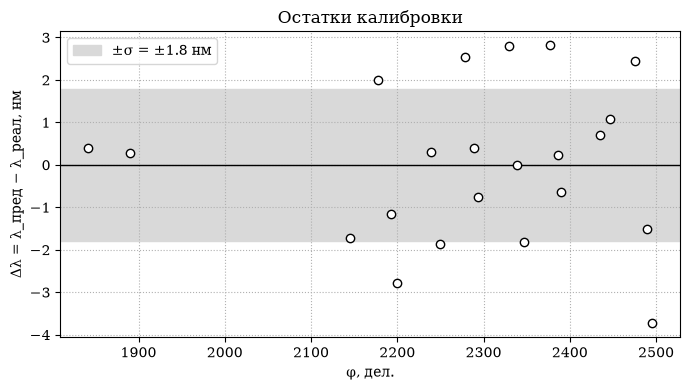

In [11]:
resid = phi_to_lambda(position) - wave_length_nm   # активная модель
plt.figure(figsize=(7, 4))
plt.axhspan(-sigma_lam, sigma_lam, color='0.85', label=f'±σ = ±{sigma_lam:.1f} нм')
plt.axhline(0, color='k', lw=1)
plt.plot(position, resid, 'o', mfc='white', mec='black')
plt.xlabel('φ, дел.'); plt.ylabel('Δλ = λ_пред − λ_реал, нм')
plt.title('Остатки калибровки'); plt.grid(True, ls=':')
plt.legend(); plt.tight_layout(); plt.show()

### Таблица остатков полинома (проверка кластеров)

Δλ и его знак по возрастанию φ. Серии одного знака подряд = кластер
(систематическое отклонение / ошибка идентификации линий), а не случайный шум.

In [12]:
# остатки поли2 независимо от активной модели
_cp = GostPlot(position, wave_length_nm).errors(dy=dlam, dx=dphi).fit(2)
b2, b1, b0 = _cp.result.params
lam_pred = b2*position**2 + b1*position + b0
d = lam_pred - wave_length_nm            # Δλ = пред − реал

order = np.argsort(position)             # по возрастанию φ
print(' φ     λ_реал  λ_пред   Δλ    знак')
for i in order:
    s = '＋' if d[i] >= 0 else '－'
    bar = s * min(int(abs(d[i])) + 1, 8)
    print(f'{position[i]:5.0f} {wave_length_nm[i]:6.1f} {lam_pred[i]:7.1f} {d[i]:+6.2f}  {bar}')
print(f'\nRMS = {np.sqrt((d**2).mean()):.2f} нм')

 φ     λ_реал  λ_пред   Δλ    знак
 1842  533.6   534.0  +0.39  ＋
 1890  540.1   540.4  +0.27  ＋
 2145  585.2   583.5  -1.71  －－
 2178  588.2   590.2  +2.00  ＋＋＋
 2193  594.5   593.3  -1.16  －－
 2200  597.6   594.8  -2.78  －－－
 2239  603.0   603.3  +0.30  ＋
 2249  607.4   605.5  -1.87  －－
 2278  609.6   612.1  +2.54  ＋＋＋
 2289  614.3   614.7  +0.40  ＋
 2293  616.4   615.6  -0.76  －
 2330  621.7   624.5  +2.80  ＋＋＋
 2339  626.7   626.7  -0.00  －
 2347  630.5   628.7  -1.83  －－
 2377  633.4   636.2  +2.82  ＋＋＋
 2386  638.3   638.5  +0.22  ＋
 2390  640.2   639.6  -0.65  －
 2435  650.7   651.4  +0.71  ＋
 2446  653.3   654.4  +1.08  ＋＋
 2475  659.9   662.4  +2.46  ＋＋＋
 2489  667.8   666.3  -1.52  －－
 2495  671.7   668.0  -3.73  －－－－

RMS = 1.79 нм


## Шаг 10. Постоянная Планка

**Теория.** Фотоэффект: $\hbar\omega = E_{\max}+W$, где $E_{\max}=eV_0$, поэтому $eV_0=\hbar\omega-W$.
Значит $V_0(\omega)=\dfrac{\hbar}{e}\,\omega-\dfrac{W}{e}$ — прямая с наклоном $k=\hbar/e$.
Запирающее $V_0$ ищем экстраполяцией в **корневых координатах**: у вакуумного фотоэлемента вблизи задержки $\sqrt{I}\propto(V_0-V)$, так что $\sqrt{I}(V)$ — прямая, и её пересечение с осью даёт $V_0$.
Частота: $\omega=2\pi c/\lambda$.
КРП (контактная разность потенциалов) добавляет к $V_0$ константу $\Rightarrow$ сдвигает прямую по вертикали, но на наклон $k=\hbar/e$ **не влияет**.

**Погрешности — в две стадии** (по методике): *стадия 1* — входные σ (вольтметр, отсчёт), *стадия 2* — эмпирические σ из RMS остатков; финальный ħ берём по стадии 2. Наклон (ħ) один и тот же, растёт только σ.

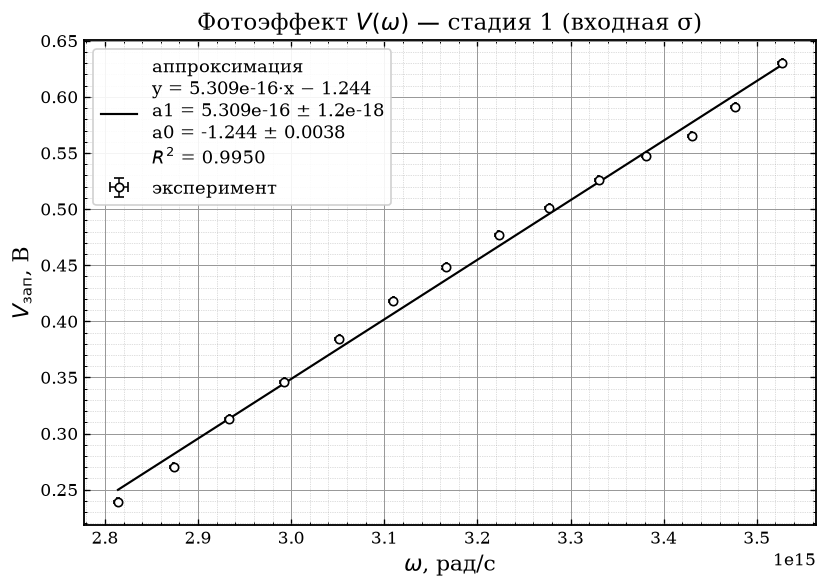

СТАДИЯ 1:  ħ = 8.507e-35 ± 1.9e-37 Дж·с  (0.2%)


In [15]:
# --- Стадия 1: ВХОДНЫЕ погрешности (σ_V прибора, σ_λ от Δφ) ---
c = 299_792_458.0
e = 1.602176634e-19
hbar_tab = 1.0546e-34
omega = 2*np.pi*c / (nm * 1e-9)

dV_input = 0.001                     # В — точность вольтметра
plot1 = (GostPlot(omega, stopping_volts)
         .xlabel(r'$\omega$', 'рад/с').ylabel(r'$V_\mathrm{зап}$', 'В')
         .title('Фотоэффект $V(\\omega)$ — стадия 1 (входная σ)')
         .errors(dy=dV_input, dx=omega * nm_q_input / nm)
         .fit(1))
plot1.show()
k1, dk1 = plot1.result.params[0], plot1.result.perr[0]
print(f'СТАДИЯ 1:  ħ = {abs(k1)*e:.3e} ± {dk1*e:.1e} Дж·с  ({dk1/abs(k1)*100:.1f}%)')

RMS остатков V(ω) = 0.0083 В   (входная была 0.0005 В)


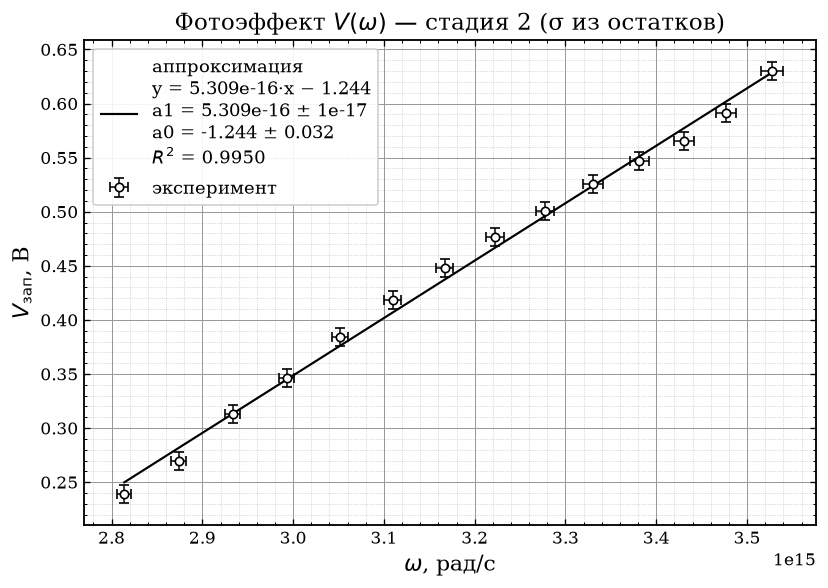

СТАДИЯ 2 (ФИНАЛ):  ħ = 8.507e-35 ± 1.6e-36 Дж·с  (1.9%)
ħ_табл = 1.0546e-34 Дж·с
отклонение от таблицы = -19%  (точность установки; систематика — анодный ток, в σ НЕ входит)


In [14]:
# --- Стадия 2: ЭМПИРИЧЕСКИЕ погрешности из остатков (ФИНАЛ) ---
resid_V = stopping_volts - (k1*omega + plot1.result.params[1])
dV_rms  = np.sqrt(np.mean(resid_V**2))     # RMS остатков V(ω)
print(f'RMS остатков V(ω) = {dV_rms:.4f} В   (входная была {dV_input} В)')

plot2 = (GostPlot(omega, stopping_volts)
         .xlabel(r'$\omega$', 'рад/с').ylabel(r'$V_\mathrm{зап}$', 'В')
         .title('Фотоэффект $V(\\omega)$ — стадия 2 (σ из остатков)')
         .errors(dy=dV_rms, dx=omega * nm_q_rms / nm)
         .fit(1))
plot2.show()
k2, dk2 = plot2.result.params[0], plot2.result.perr[0]
hbar = abs(k2)*e
print(f'СТАДИЯ 2 (ФИНАЛ):  ħ = {hbar:.3e} ± {dk2*e:.1e} Дж·с  ({dk2/abs(k2)*100:.1f}%)')
print(f'ħ_табл = {hbar_tab:.4e} Дж·с')
print(f'отклонение от таблицы = {(hbar/hbar_tab-1)*100:+.0f}%  '
      f'(точность установки; систематика — анодный ток, в σ НЕ входит)')

## Приложение. Как считаются погрешности параметров (МНК)

**Полином — это линейный МНК**, поэтому всё в замкнутом виде.

Модель $\lambda=\sum_j a_j\,\varphi^{\,p-j}$ линейна по $a_j$. Строим **матрицу плана** (Вандермонда) $X_{ij}=\varphi_i^{\,p-j}$ и диагональную матрицу весов $W=\mathrm{diag}(1/\sigma_i^2)$, где $\sigma_i$ — погрешность точки (у нас $\sigma=\Delta\lambda$).

**Нормальные уравнения** и их решение:
$$X^{\mathsf T}WX\,\mathbf a = X^{\mathsf T}W\,\boldsymbol\lambda \quad\Rightarrow\quad \mathbf a=(X^{\mathsf T}WX)^{-1}X^{\mathsf T}W\,\boldsymbol\lambda.$$

**Ковариационная матрица коэффициентов:**
$$\mathrm{Cov}(\mathbf a)=(X^{\mathsf T}WX)^{-1},\qquad \sigma(a_j)=\sqrt{\mathrm{Cov}(\mathbf a)_{jj}}.$$

Это и есть напечатанные `a2 ± …, a1 ± …, a0 ± …`. Именно так работает `np.polyfit(phi, lam, deg, w=1/sigma, cov=...)` внутри `gostplot`.

**Две стадии (как в работе):**
- *входная* $\sigma$ (`absolute_sigma=True`, `cov='unscaled'`) — берём $\sigma_i$ как заявленные; $\mathrm{Cov}=(X^{\mathsf T}WX)^{-1}$.
- *эмпирическая* $\sigma$ (`absolute_sigma=False`) — Cov домножается на $\chi^2/(n-p)$, т.е. масштабируется по реальному разбросу остатков ($n$ точек, $p$ параметров).

**Гартман** — нелинейная модель, поэтому `curve_fit` (Левенберга–Марквардта) линеаризует её в минимуме: та же формула, только вместо Вандермонда — якобиан $J_{ij}=\partial f/\partial a_j$, и $\mathrm{Cov}=(J^{\mathsf T}WJ)^{-1}$.

**Проверка:** ручной расчёт $(X^{\mathsf T}WX)^{-1}$ совпал с выводом `gostplot` до последней цифры (и коэффициенты, и $\sigma$).